# **PHASE 1 – Dataset Creation**

# Step 1 – Create Dataset Using Python

In [2]:
import pandas as pd
import numpy as np

In [3]:
np.random.seed(42)

In [4]:
clients = ["KOP Studios", "Aishwarya Design", "Local Cafe", "Tech Startup",
           "Fitness Studio", "Clothing Brand", "Photography Hub", "Coaching Center"]

In [5]:
industries = ["Media", "Design", "Food", "Technology",
              "Fitness", "Retail", "Photography", "Education"]

In [6]:
project_types = ["Portfolio", "Business Website", "E-commerce", "Branding"]

In [7]:
cities = ["Kolhapur", "Pune", "Mumbai", "Bangalore"]

In [8]:
data = {
    "client_id": range(1, 101),
    "client_name": np.random.choice(clients, 100),
    "industry": np.random.choice(industries, 100),
    "project_type": np.random.choice(project_types, 100),
    "project_cost": np.random.randint(15000, 150000, 100),
    "start_date": pd.date_range(start="2023-01-01", periods=100, freq="7D"),
    "payment_status": np.random.choice(["Paid", "Pending"], 100),
    "city": np.random.choice(cities, 100)
}

In [9]:
df = pd.DataFrame(data)

In [10]:
df.head()

,client_id,client_name,industry,project_type,project_cost,start_date,payment_status,city
0,1,Photography Hub,Photography,E-commerce,22392,2023-01-01,Pending,Pune
1,2,Tech Startup,Design,Branding,70680,2023-01-08,Paid,Pune
2,3,Fitness Studio,Design,E-commerce,65859,2023-01-15,Pending,Pune
3,4,Photography Hub,Technology,Portfolio,140657,2023-01-22,Pending,Pune
4,5,Local Cafe,Design,Branding,85467,2023-01-29,Pending,Kolhapur


# **PHASE 2 – Data Cleaning & Understanding**

# Step 2 – Basic Exploration

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   client_id       100 non-null    int64         
 1   client_name     100 non-null    object        
 2   industry        100 non-null    object        
 3   project_type    100 non-null    object        
 4   project_cost    100 non-null    int64         
 5   start_date      100 non-null    datetime64[ns]
 6   payment_status  100 non-null    object        
 7   city            100 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 6.4+ KB


In [13]:
df.describe()

,client_id,project_cost,start_date
count,100.000000,100.000000,100
mean,50.500000,89056.490000,2023-12-13 12:00:00
min,1.000000,17869.000000,2023-01-01 00:00:00
25%,25.750000,53146.000000,2023-06-23 06:00:00
50%,50.500000,97759.500000,2023-12-13 12:00:00
75%,75.250000,125426.500000,2024-06-03 18:00:00
max,100.000000,149508.000000,2024-11-24 00:00:00
std,29.011492,41147.735789,NaN


In [14]:
df.isnull().sum()

,0
client_id,0
client_name,0
industry,0
project_type,0
project_cost,0
start_date,0
payment_status,0
city,0


# **PHASE 3 – Exploratory Data Analysis (EDA)**

Total Revenue

In [15]:
total_revenue = df['project_cost'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 8905649


Revenue by Project Type

In [16]:
revenue_by_project = df.groupby('project_type')['project_cost'].sum()
print("Revenue by Project Type:")
print(revenue_by_project)

Revenue by Project Type:
project_type
Branding            2460861
Business Website    2149215
E-commerce          1755317
Portfolio           2540256
Name: project_cost, dtype: int64


Visualization

In [17]:
import matplotlib.pyplot as plt

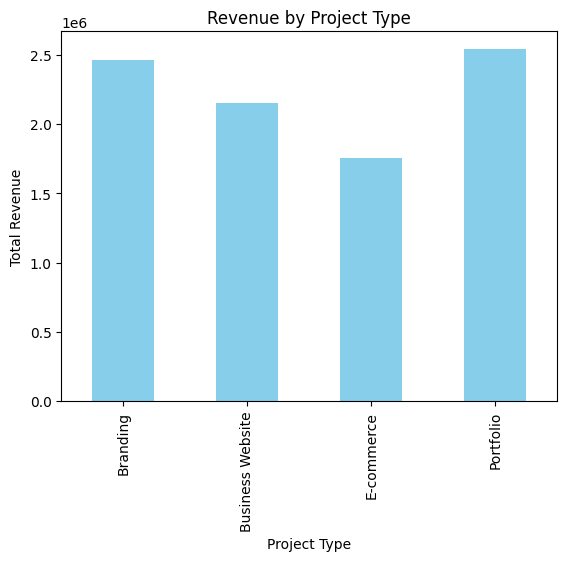

In [18]:
revenue_by_project.plot(kind='bar', color='skyblue')
plt.title('Revenue by Project Type')
plt.xlabel('Project Type')
plt.ylabel('Total Revenue')
plt.show()

# **PHASE 4 – Monthly Revenue Trend Analysis**

# Step 1 – Extract Month & Year

In [19]:
df['start_date'] = pd.to_datetime(df['start_date'])
df['year_month'] = df['start_date'].dt.to_period('M')

In [20]:
df.head()

,client_id,client_name,industry,project_type,project_cost,start_date,payment_status,city,year_month
0,1,Photography Hub,Photography,E-commerce,22392,2023-01-01,Pending,Pune,2023-01
1,2,Tech Startup,Design,Branding,70680,2023-01-08,Paid,Pune,2023-01
2,3,Fitness Studio,Design,E-commerce,65859,2023-01-15,Pending,Pune,2023-01
3,4,Photography Hub,Technology,Portfolio,140657,2023-01-22,Pending,Pune,2023-01
4,5,Local Cafe,Design,Branding,85467,2023-01-29,Pending,Kolhapur,2023-01


# Step 2 – Monthly Revenue Calculation

In [21]:
monthly_revenue = df.groupby('year_month')['project_cost'].sum()

print("Monthly Revenue Trend:")
print(monthly_revenue)

Monthly Revenue Trend:
year_month
2023-01    385055
2023-02    412505
2023-03    396132
2023-04    467958
2023-05    269088
2023-06    486929
2023-07    500617
2023-08    249644
2023-09    281117
2023-10    455706
2023-11    515832
2023-12    363876
2024-01    264198
2024-02    372291
2024-03    367832
2024-04    386618
2024-05    309603
2024-06    433542
2024-07    425090
2024-08    301615
2024-09    480181
2024-10    368765
2024-11    411455
Freq: M, Name: project_cost, dtype: int64


# Step 3 – Line Plot (Very Important)

In [22]:
import matplotlib.pyplot as plt

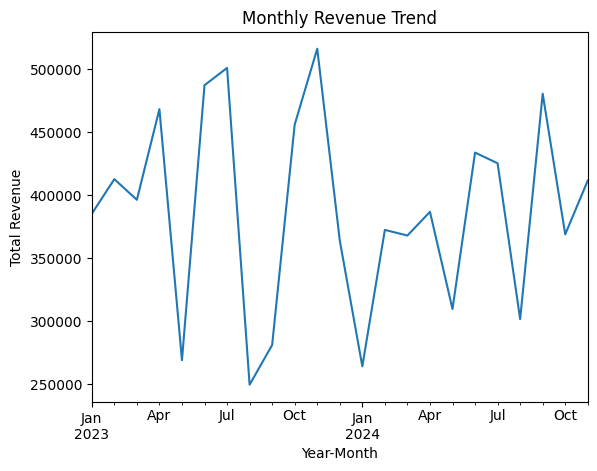

In [23]:
monthly_revenue.plot()
plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
plt.show()

# **PHASE 5 – Revenue Growth Rate**

In [24]:
monthly_growth = monthly_revenue.pct_change() * 100

print("Monthly Revenue Growth Rate:")
print(monthly_growth)

Monthly Revenue Growth Rate:
year_month
2023-01          NaN
2023-02     7.128852
2023-03    -3.969164
2023-04    18.131835
2023-05   -42.497404
2023-06    80.955301
2023-07     2.811087
2023-08   -50.132736
2023-09    12.607153
2023-10    62.105458
2023-11    13.194033
2023-12   -29.458428
2024-01   -27.393398
2024-02    40.913633
2024-03    -1.197719
2024-04     5.107223
2024-05   -19.920180
2024-06    40.031589
2024-07    -1.949523
2024-08   -29.046790
2024-09    59.203289
2024-10   -23.202917
2024-11    11.576478
Freq: M, Name: project_cost, dtype: float64


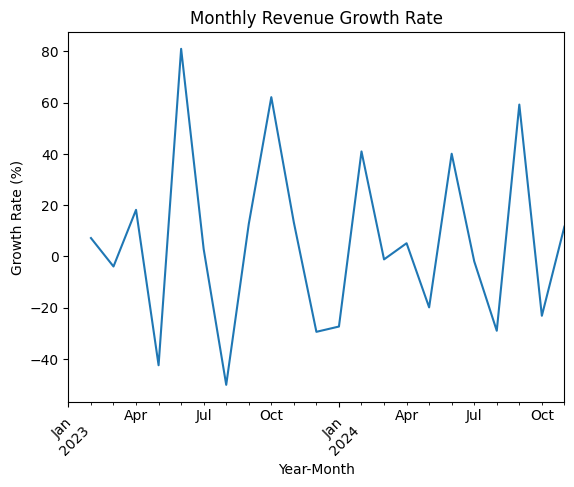

In [25]:
monthly_growth.plot()
plt.title('Monthly Revenue Growth Rate')
plt.xlabel('Year-Month')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45)
plt.show()

# **PHASE 6 – Convert This Into ML Problem**

Step 1 – Create Target Variable

In [26]:
df['high_value_project'] = df['project_cost'].apply(lambda x: 1 if x >= 80000 else 0)

df.head()

,client_id,client_name,industry,project_type,project_cost,start_date,payment_status,city,year_month,high_value_project
0,1,Photography Hub,Photography,E-commerce,22392,2023-01-01,Pending,Pune,2023-01,0
1,2,Tech Startup,Design,Branding,70680,2023-01-08,Paid,Pune,2023-01,0
2,3,Fitness Studio,Design,E-commerce,65859,2023-01-15,Pending,Pune,2023-01,0
3,4,Photography Hub,Technology,Portfolio,140657,2023-01-22,Pending,Pune,2023-01,1
4,5,Local Cafe,Design,Branding,85467,2023-01-29,Pending,Kolhapur,2023-01,1


Step 2 – Encode Categorical Columns

In [27]:
df_encoded = pd.get_dummies(df, columns=['industry', 'project_type', 'city'], drop_first=True)

df_encoded.head()

,client_id,client_name,project_cost,start_date,payment_status,year_month,high_value_project,industry_Education,industry_Fitness,industry_Food,industry_Media,industry_Photography,industry_Retail,industry_Technology,project_type_Business Website,project_type_E-commerce,project_type_Portfolio,city_Kolhapur,city_Mumbai,city_Pune
0,1,Photography Hub,22392,2023-01-01,Pending,2023-01,0,False,False,False,False,True,False,False,False,True,False,False,False,True
1,2,Tech Startup,70680,2023-01-08,Paid,2023-01,0,False,False,False,False,False,False,False,False,False,False,False,False,True
2,3,Fitness Studio,65859,2023-01-15,Pending,2023-01,0,False,False,False,False,False,False,False,False,True,False,False,False,True
3,4,Photography Hub,140657,2023-01-22,Pending,2023-01,1,False,False,False,False,False,False,True,False,False,True,False,False,True
4,5,Local Cafe,85467,2023-01-29,Pending,2023-01,1,False,False,False,False,False,False,False,False,False,False,True,False,False


Step 3 – Select Features

In [28]:
X = df_encoded.drop(["client_id", "client_name", "project_cost", "start_date", "year_month", "payment_status", "high_value_project"], axis=1)
y = df_encoded["high_value_project"]

Step 4 – Train/Test Split

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 5 – Train Model

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Step 6 – Evaluate

In [33]:
from sklearn.metrics import accuracy_score, classification_report

In [34]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.55


# **Step 1 – Train Random Forest**

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# **Step 2 – Evaluate Random Forest**

In [37]:
rf_pred = rf_model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score, classification_report

In [41]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.6
              precision    recall  f1-score   support

           0       0.43      0.43      0.43         7
           1       0.69      0.69      0.69        13

    accuracy                           0.60        20
   macro avg       0.56      0.56      0.56        20
weighted avg       0.60      0.60      0.60        20



# **Step 3 – Confusion Matrix**

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [43]:
cm = confusion_matrix(y_test, rf_pred)

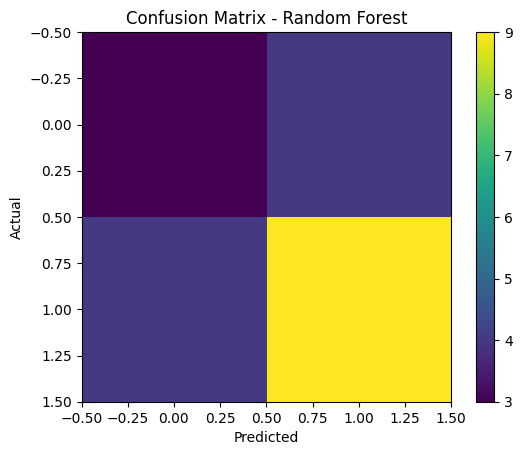

[[3 4]
 [4 9]]


In [44]:
plt.imshow(cm)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()

print(cm)

# **Step 4 – Feature Importance**

In [45]:
import pandas as pd

In [46]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

city_Kolhapur                    0.102479
project_type_E-commerce          0.102412
city_Mumbai                      0.094460
project_type_Business Website    0.085856
project_type_Portfolio           0.084802
city_Pune                        0.079403
industry_Photography             0.074349
industry_Technology              0.069774
industry_Media                   0.068884
industry_Food                    0.067759
dtype: float64


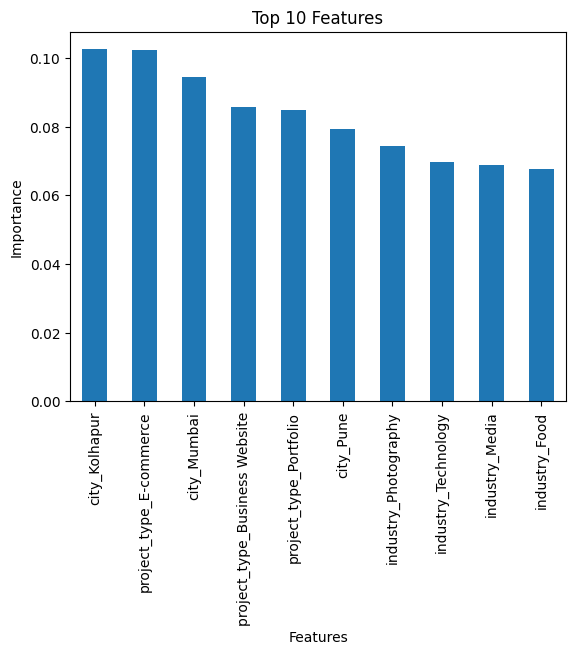

In [47]:
feature_importance.head(10).plot(kind='bar')
plt.title('Top 10 Features')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()